In [2]:
# %pip -q install requests tqdm remotezip soundfile scipy h5py mat73 pandas matplotlib

In [3]:
from pathlib import Path, PurePosixPath
from urllib.parse import quote
import hashlib
import json
import os
import shutil
import zipfile

import requests
from tqdm.auto import tqdm

RECORD_ID = "14057061"

# Everything stays inside this notebook working directory.
BASE_DIR = Path.cwd() / "yang_long_2025_budgie_aac"
DATA_DIR = BASE_DIR / "data"
DOWNLOAD_DIR = BASE_DIR / "downloads"

DATA_DIR.mkdir(parents=True, exist_ok=True)
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

# Parrot / budgerigar folders from the Zenodo README.
BUDGIE_FOLDERS = [
    "Bl122_ChronicLeftAAC",
    "Li145_ChronicLeftAAC",
    "Or61_ChronicLeftAAC",
    "Ti81_ChronicLeftAAC",
]

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)

BASE_DIR: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac
DATA_DIR: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data


In [4]:
def human_size(n_bytes):
    n = float(n_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} PB"


def zenodo_file_key(file_record):
    return file_record.get("key") or file_record.get("filename")


def zenodo_file_url(file_record):
    """
    Prefer the Zenodo API content link.
    Fall back to the public records/files URL if needed.
    """
    key = zenodo_file_key(file_record)
    links = file_record.get("links", {})
    return (
        links.get("content")
        or links.get("self")
        or f"https://zenodo.org/records/{RECORD_ID}/files/{quote(key)}?download=1"
    )


api_url = f"https://zenodo.org/api/records/{RECORD_ID}"
resp = requests.get(api_url, timeout=60)
resp.raise_for_status()
record = resp.json()

files = {zenodo_file_key(f): f for f in record["files"]}

print("Zenodo title:", record["metadata"]["title"])
print("\nFiles:")
for key, f in files.items():
    size = f.get("size", None)
    checksum = f.get("checksum", "")
    print(f"  {key:10s}  {human_size(size) if size else 'unknown'}  {checksum}")

DATA_ZIP_URL = zenodo_file_url(files["Data.zip"])
README_URL = zenodo_file_url(files["README.md"])
CODE_ZIP_URL = zenodo_file_url(files["Code.zip"])

print("\nData.zip URL resolved.")

Zenodo title: Data and code for 'Convergent vocal representations in parrot and human forebrain motor networks'

Files:
  README.md   2.8 KB  md5:1cfa68c49f8032f8605b53108c7f70ce
  Data.zip    14.6 GB  md5:bd45bd56d2adffbc2a12ffd1cdd516f0
  Code.zip    56.8 KB  md5:4f4f10ed5c4f73b2889b34cbae3b83ae

Data.zip URL resolved.


In [5]:
def download_small_file(url, out_path):
    out_path = Path(out_path)
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f"Already exists: {out_path}")
        return out_path

    with requests.get(url, stream=True, timeout=(30, 120)) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(out_path, "wb") as f, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc=out_path.name,
        ) as pbar:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    return out_path


readme_path = download_small_file(README_URL, DOWNLOAD_DIR / "README.md")
code_zip_path = download_small_file(CODE_ZIP_URL, DOWNLOAD_DIR / "Code.zip")

print("\nREADME preview:")
print(readme_path.read_text(errors="replace")[:1500])

README.md:   0%|          | 0.00/2.89k [00:00<?, ?B/s]

Code.zip:   0%|          | 0.00/58.2k [00:00<?, ?B/s]


README preview:
# BudgieAAC

Data and code for the budgie AAC project.

## System requirements

All code was tested on Matlab 2023a running on Windows 10.

### Dependencies

- 200 colormap: https://www.mathworks.com/matlabcentral/fileexchange/120088-200-colormap
- DataViz: https://github.com/povilaskarvelis/DataViz
- mseb: https://www.mathworks.com/matlabcentral/fileexchange/47950-mseb-x-y-errbar-lineprops-transparent
- arrow: https://www.mathworks.com/matlabcentral/fileexchange/278-arrow
- venn: https://www.mathworks.com/matlabcentral/fileexchange/22282-venn
- cumstom colormap: https://www.mathworks.com/matlabcentral/fileexchange/42450-custom-colormap
- rgb: https://www.mathworks.com/matlabcentral/fileexchange/24497-rgb-triple-of-color-name-version-2

## Instructions

1. Copy all code files into a local folder.
2. Download the dataset from Zenodo and unzip all files into the same folder as the code.
3. Create a subfolder named `Paper` for saving figures.
4. Run `publish.m`.

The file

In [6]:
from remotezip import RemoteZip


def is_budgie_member(zip_name):
    parts = PurePosixPath(zip_name).parts
    return any(folder in parts for folder in BUDGIE_FOLDERS)


def strip_prefix_to_bird(zip_name):
    """
    If ZIP contains e.g.
        Data/Bl122_ChronicLeftAAC/sua.mat
    return
        Bl122_ChronicLeftAAC/sua.mat
    """
    parts = PurePosixPath(zip_name).parts
    for i, part in enumerate(parts):
        if part in BUDGIE_FOLDERS:
            return Path(*parts[i:])
    raise ValueError(f"No budgie folder found in path: {zip_name}")


with RemoteZip(DATA_ZIP_URL) as rz:
    all_infos = rz.infolist()

    budgie_infos = [
        zi for zi in all_infos
        if (not zi.is_dir()) and is_budgie_member(zi.filename)
    ]

    print(f"Total files in remote ZIP: {len(all_infos)}")
    print(f"Budgerigar files selected: {len(budgie_infos)}")

    if len(budgie_infos) == 0:
        raise RuntimeError(
            "No budgerigar files found. The ZIP structure may have changed."
        )

    total_uncompressed = sum(zi.file_size for zi in budgie_infos)
    print("Selected uncompressed size:", human_size(total_uncompressed))

    with tqdm(
        total=total_uncompressed,
        unit="B",
        unit_scale=True,
        desc="Extracting budgerigar data",
    ) as pbar:
        for zi in budgie_infos:
            rel_path = strip_prefix_to_bird(zi.filename)
            out_path = DATA_DIR / rel_path
            out_path.parent.mkdir(parents=True, exist_ok=True)

            with rz.open(zi.filename) as src, open(out_path, "wb") as dst:
                while True:
                    chunk = src.read(1024 * 1024)
                    if not chunk:
                        break
                    dst.write(chunk)
                    pbar.update(len(chunk))

print("Done.")

Total files in remote ZIP: 67
Budgerigar files selected: 10
Selected uncompressed size: 3.4 GB


Extracting budgerigar data:   0%|          | 0.00/3.61G [00:00<?, ?B/s]

Done.


In [7]:
for folder in BUDGIE_FOLDERS:
    bird_dir = DATA_DIR / folder
    sua_path = bird_dir / "sua.mat"
    audio_path = bird_dir / "audioCh3_HP.flac"

    print("\n" + "=" * 80)
    print(folder)
    print("folder exists:", bird_dir.exists())
    print("sua.mat:", sua_path.exists(), human_size(sua_path.stat().st_size) if sua_path.exists() else "")
    print("audioCh3_HP.flac:", audio_path.exists(), human_size(audio_path.stat().st_size) if audio_path.exists() else "")

    if bird_dir.exists():
        n_files = sum(1 for p in bird_dir.rglob("*") if p.is_file())
        print("number of files:", n_files)


Bl122_ChronicLeftAAC
folder exists: True
sua.mat: True 636.9 MB
audioCh3_HP.flac: True 270.3 MB
number of files: 4

Li145_ChronicLeftAAC
folder exists: True
sua.mat: True 852.2 MB
audioCh3_HP.flac: True 234.5 MB
number of files: 2

Or61_ChronicLeftAAC
folder exists: True
sua.mat: True 98.8 MB
audioCh3_HP.flac: True 34.0 MB
number of files: 2

Ti81_ChronicLeftAAC
folder exists: True
sua.mat: True 736.6 MB
audioCh3_HP.flac: True 295.9 MB
number of files: 2


In [8]:
import scipy.io as sio
import h5py


def inspect_mat_file(path, max_hdf5_depth=2):
    path = Path(path)
    print("\n" + "=" * 80)
    print(path)

    try:
        info = sio.whosmat(path)
        print("MATLAB <= v7.2 style file. Variables:")
        for name, shape, dtype in info:
            print(f"  {name:30s} shape={shape}, dtype={dtype}")
        return

    except NotImplementedError:
        print("MATLAB v7.3 / HDF5 style file. HDF5 tree:")

    except Exception as e:
        print("scipy.io.whosmat failed with:")
        print(repr(e))
        print("Trying HDF5 inspection...")

    def visit(name, obj):
        depth = name.count("/")
        if depth <= max_hdf5_depth:
            if isinstance(obj, h5py.Dataset):
                print(f"  {name:50s} dataset shape={obj.shape}, dtype={obj.dtype}")
            else:
                print(f"  {name:50s} group")

    with h5py.File(path, "r") as f:
        f.visititems(visit)


for folder in BUDGIE_FOLDERS:
    inspect_mat_file(DATA_DIR / folder / "sua.mat")


/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/Bl122_ChronicLeftAAC/sua.mat
MATLAB <= v7.2 style file. Variables:
  sua                            shape=(1, 43), dtype=struct
  suaInfo                        shape=(1, 1), dtype=struct
  suaWav                         shape=(1, 43), dtype=struct

/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/Li145_ChronicLeftAAC/sua.mat
MATLAB <= v7.2 style file. Variables:
  sua                            shape=(1, 81), dtype=struct
  suaInfo                        shape=(1, 1), dtype=struct
  suaWav                         shape=(1, 81), dtype=struct

/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/Or61_ChronicLeftAAC/sua.mat
MATLAB <= v7.2 style file. Variables:
  sua                            shape=(1, 47), dtype=struct
  suaInfo                        shape=(1, 1), dtype=struct
  suaWav                         shape=(1, 47), dtype=struct

/home/ganchao/Desktop/audio_convergent/y

In [9]:
import numpy as np
import mat73


def load_mat_any(path):
    """
    Loads either old-style MATLAB .mat files or v7.3 HDF5 .mat files.
    """
    path = Path(path)

    try:
        return sio.loadmat(
            path,
            squeeze_me=True,
            struct_as_record=False,
            simplify_cells=True,
        )
    except NotImplementedError:
        return mat73.loadmat(path)


def summarize_obj(obj, name="obj", depth=0, max_depth=3, max_items=10):
    indent = "  " * depth

    if isinstance(obj, dict):
        print(f"{indent}{name}: dict with {len(obj)} keys")
        if depth < max_depth:
            for k in list(obj.keys())[:max_items]:
                if not str(k).startswith("__"):
                    summarize_obj(obj[k], str(k), depth + 1, max_depth, max_items)

    elif isinstance(obj, np.ndarray):
        print(f"{indent}{name}: ndarray shape={obj.shape}, dtype={obj.dtype}")
        if obj.dtype == object and obj.size > 0 and depth < max_depth:
            summarize_obj(obj.flat[0], name + "[0]", depth + 1, max_depth, max_items)

    elif hasattr(obj, "__dict__"):
        keys = [k for k in vars(obj).keys() if not k.startswith("_")]
        print(f"{indent}{name}: MATLAB struct-like object with fields {keys[:max_items]}")
        if depth < max_depth:
            for k in keys[:max_items]:
                summarize_obj(getattr(obj, k), k, depth + 1, max_depth, max_items)

    else:
        print(f"{indent}{name}: {type(obj).__name__} = {repr(obj)[:120]}")


bird = "Bl122_ChronicLeftAAC"
sua_path = DATA_DIR / bird / "sua.mat"

sua = load_mat_any(sua_path)

print("Loaded:", sua_path)
summarize_obj(sua, "sua")

Loaded: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/Bl122_ChronicLeftAAC/sua.mat
sua: dict with 6 keys
  sua: list = [{'spikeTimes': array([1.95000000e-02, 3.72000000e-02, 5.62000000e-02, ...,
       1.61999522e+04, 1.61999680e+04, 1.619
  suaInfo: dict with 8 keys
    dataDir: str = 'C:\\WorkAtLongLab\\Bl122_ChronicLeftAAC\\Bl122_230625_092844_cut0-16200\\kilosort2.5'
    datFile: str = 'temp_wh.dat'
    nChannel: int = 128
    dtype: str = 'int16'
    sampleRate: int = 30000
    spikeTimes: ndarray shape=(41336540,), dtype=float64
    spikeClusters: ndarray shape=(41336540,), dtype=uint16
    winv: ndarray shape=(128, 128), dtype=uint8
  suaWav: list = [{'spikeTimes': array([1.95000000e-02, 3.72000000e-02, 5.62000000e-02, ...,
       1.61999522e+04, 1.61999680e+04, 1.619


In [10]:
import soundfile as sf

for folder in BUDGIE_FOLDERS:
    audio_path = DATA_DIR / folder / "audioCh3_HP.flac"
    print("\n" + "=" * 80)
    print(folder)
    print(sf.info(str(audio_path)))


Bl122_ChronicLeftAAC
/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/Bl122_ChronicLeftAAC/audioCh3_HP.flac
samplerate: 30000 Hz
channels: 1
duration: 4:3e+01:0.000 h
format: FLAC (Free Lossless Audio Codec) [FLAC]
subtype: Signed 16 bit PCM [PCM_16]

Li145_ChronicLeftAAC
/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/Li145_ChronicLeftAAC/audioCh3_HP.flac
samplerate: 30000 Hz
channels: 1
duration: 4:4e+01:6.743 h
format: FLAC (Free Lossless Audio Codec) [FLAC]
subtype: Signed 16 bit PCM [PCM_16]

Or61_ChronicLeftAAC
/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/Or61_ChronicLeftAAC/audioCh3_HP.flac
samplerate: 30000 Hz
channels: 1
duration: 3e+01:1.000 min
format: FLAC (Free Lossless Audio Codec) [FLAC]
subtype: Signed 16 bit PCM [PCM_16]

Ti81_ChronicLeftAAC
/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/Ti81_ChronicLeftAAC/audioCh3_HP.flac
samplerate: 30000 Hz
channels: 1
duration: 5:3e+01:0.00

audio shape: (150000,)
sampling rate: 30000


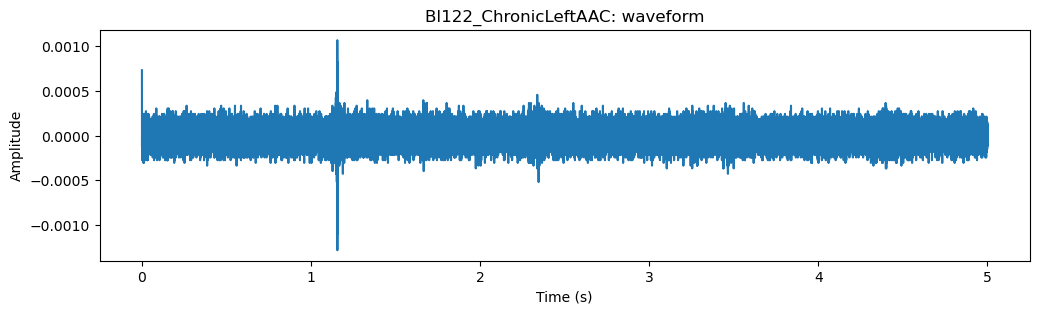

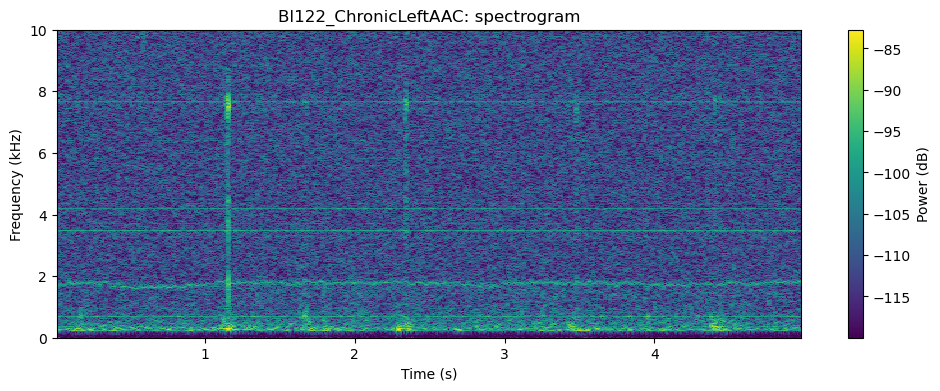

In [11]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

bird = "Bl122_ChronicLeftAAC"
audio_path = DATA_DIR / bird / "audioCh3_HP.flac"

info = sf.info(str(audio_path))
fs = info.samplerate

# Read only a short chunk to avoid loading the whole file.
start_sec = 0
duration_sec = 5

start_frame = int(start_sec * fs)
stop_frame = int((start_sec + duration_sec) * fs)

audio, fs = sf.read(
    str(audio_path),
    start=start_frame,
    stop=stop_frame,
    always_2d=False,
)

if audio.ndim > 1:
    audio = audio[:, 0]

print("audio shape:", audio.shape)
print("sampling rate:", fs)

plt.figure(figsize=(12, 3))
t = np.arange(len(audio)) / fs + start_sec
plt.plot(t, audio)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"{bird}: waveform")
plt.show()

f, tt, Sxx = spectrogram(
    audio,
    fs=fs,
    nperseg=1024,
    noverlap=768,
    scaling="spectrum",
)

plt.figure(figsize=(12, 4))
plt.pcolormesh(
    tt + start_sec,
    f / 1000,
    10 * np.log10(Sxx + 1e-12),
    shading="auto",
)
plt.ylim(0, 10)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (kHz)")
plt.title(f"{bird}: spectrogram")
plt.colorbar(label="Power (dB)")
plt.show()

In [13]:
# Run this cell only if Cell 5 fails.
# This downloads the full 15.7 GB Data.zip, then extracts only the budgerigar folders locally.

RUN_FULL_ZIP_FALLBACK = False

def md5sum(path, chunk_size=1024 * 1024 * 8):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def download_with_resume(url, out_path):
    out_path = Path(out_path)
    tmp_size = out_path.stat().st_size if out_path.exists() else 0

    headers = {}
    mode = "wb"

    if tmp_size > 0:
        headers["Range"] = f"bytes={tmp_size}-"
        mode = "ab"

    with requests.get(url, stream=True, headers=headers, timeout=(30, 120)) as r:
        if tmp_size > 0 and r.status_code != 206:
            print("Server did not accept resume; restarting download.")
            tmp_size = 0
            mode = "wb"
            r.close()
            return download_with_resume(url, out_path)

        r.raise_for_status()

        content_length = int(r.headers.get("content-length", 0))
        total = tmp_size + content_length if content_length else None

        with open(out_path, mode) as f, tqdm(
            total=total,
            initial=tmp_size,
            unit="B",
            unit_scale=True,
            desc=out_path.name,
        ) as pbar:
            for chunk in r.iter_content(chunk_size=1024 * 1024 * 8):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

    return out_path


def extract_budgie_from_local_zip(zip_path, out_dir):
    zip_path = Path(zip_path)
    out_dir = Path(out_dir)

    with zipfile.ZipFile(zip_path) as zf:
        infos = [
            zi for zi in zf.infolist()
            if (not zi.is_dir()) and is_budgie_member(zi.filename)
        ]

        print("Budgerigar files selected:", len(infos))
        total_uncompressed = sum(zi.file_size for zi in infos)
        print("Selected uncompressed size:", human_size(total_uncompressed))

        with tqdm(
            total=total_uncompressed,
            unit="B",
            unit_scale=True,
            desc="Extracting budgerigar data",
        ) as pbar:
            for zi in infos:
                rel_path = strip_prefix_to_bird(zi.filename)
                out_path = out_dir / rel_path
                out_path.parent.mkdir(parents=True, exist_ok=True)

                with zf.open(zi) as src, open(out_path, "wb") as dst:
                    while True:
                        chunk = src.read(1024 * 1024)
                        if not chunk:
                            break
                        dst.write(chunk)
                        pbar.update(len(chunk))


if RUN_FULL_ZIP_FALLBACK:
    data_zip_path = DOWNLOAD_DIR / "Data.zip"
    download_with_resume(DATA_ZIP_URL, data_zip_path)

    expected_md5 = files["Data.zip"].get("checksum", "").replace("md5:", "")
    if expected_md5:
        observed_md5 = md5sum(data_zip_path)
        print("expected md5:", expected_md5)
        print("observed md5:", observed_md5)
        assert observed_md5 == expected_md5, "MD5 mismatch!"

    extract_budgie_from_local_zip(data_zip_path, DATA_DIR)
    print("Fallback extraction done.")
else:
    print("Fallback disabled. Set RUN_FULL_ZIP_FALLBACK = True only if needed.")

Fallback disabled. Set RUN_FULL_ZIP_FALLBACK = True only if needed.


# save data

In [14]:
from pathlib import Path
import json
import gc

import numpy as np
import pandas as pd
import scipy.io as sio
import h5py
import soundfile as sf
from tqdm.auto import tqdm

BASE_DIR = Path.cwd() / "yang_long_2025_budgie_aac"
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = BASE_DIR / "processed"

BUDGIE_FOLDERS = [
    "Bl122_ChronicLeftAAC",
    "Li145_ChronicLeftAAC",
    "Or61_ChronicLeftAAC",
    "Ti81_ChronicLeftAAC",
]

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

DATA_DIR: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data
PROCESSED_DIR: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed


In [15]:
def human_size(n_bytes):
    n = float(n_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} PB"


for bird in BUDGIE_FOLDERS:
    bird_dir = DATA_DIR / bird
    print("\n" + "=" * 100)
    print(bird)

    if not bird_dir.exists():
        print("MISSING:", bird_dir)
        continue

    for p in sorted(bird_dir.rglob("*")):
        if p.is_file():
            print(f"{p.relative_to(DATA_DIR)}    {human_size(p.stat().st_size)}")


Bl122_ChronicLeftAAC
Bl122_ChronicLeftAAC/audioCh2_HP.flac    286.0 MB
Bl122_ChronicLeftAAC/audioCh3_HP.flac    270.3 MB
Bl122_ChronicLeftAAC/exampleResp.txt    1.2 KB
Bl122_ChronicLeftAAC/sua.mat    636.9 MB

Li145_ChronicLeftAAC
Li145_ChronicLeftAAC/audioCh3_HP.flac    234.5 MB
Li145_ChronicLeftAAC/sua.mat    852.2 MB

Or61_ChronicLeftAAC
Or61_ChronicLeftAAC/audioCh3_HP.flac    34.0 MB
Or61_ChronicLeftAAC/sua.mat    98.8 MB

Ti81_ChronicLeftAAC
Ti81_ChronicLeftAAC/audioCh3_HP.flac    295.9 MB
Ti81_ChronicLeftAAC/sua.mat    736.6 MB


In [16]:
def load_sua_mat(path):
    """
    Load MATLAB <= v7.2 .mat file and simplify structs/cells.
    Important: this loads one bird at a time, because these files are large.
    """
    return sio.loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
        simplify_cells=True,
    )


def as_list(x):
    """
    Convert MATLAB cell/struct arrays into a Python list.
    """
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, np.ndarray):
        if x.ndim == 0:
            return [x.item()]
        return list(x.ravel())
    return [x]


def get_field(obj, key, default=None):
    """
    Work with dict-like MATLAB structs.
    """
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(key, default)
    if hasattr(obj, key):
        return getattr(obj, key)
    return default


def field_names(obj):
    if obj is None:
        return []
    if isinstance(obj, dict):
        return sorted([k for k in obj.keys() if not str(k).startswith("__")])
    if hasattr(obj, "__dict__"):
        return sorted([k for k in vars(obj).keys() if not k.startswith("_")])
    return []


def to_1d_float_array(x):
    if x is None:
        return np.array([], dtype=np.float64)
    arr = np.asarray(x)
    if arr.size == 0:
        return np.array([], dtype=np.float64)
    return arr.astype(np.float64, copy=False).ravel()


def json_safe(x):
    """
    Convert numpy/scipy objects into JSON-safe summaries.
    Avoid dumping huge arrays.
    """
    if isinstance(x, (str, int, float, bool)) or x is None:
        return x

    if isinstance(x, bytes):
        return x.decode(errors="replace")

    if isinstance(x, (np.integer, np.floating, np.bool_)):
        return x.item()

    if isinstance(x, np.ndarray):
        out = {
            "type": "ndarray",
            "shape": list(x.shape),
            "dtype": str(x.dtype),
        }
        if x.size <= 10:
            out["values"] = x.tolist()
        return out

    if isinstance(x, dict):
        return {str(k): json_safe(v) for k, v in x.items() if not str(k).startswith("__")}

    if isinstance(x, (list, tuple)):
        if len(x) <= 10:
            return [json_safe(v) for v in x]
        return {
            "type": "list",
            "length": len(x),
            "first_item_summary": json_safe(x[0]),
        }

    return repr(x)


def describe_value(x):
    """
    Compact value description for fields.
    """
    if isinstance(x, dict):
        return {
            "type": "dict",
            "keys": field_names(x),
        }

    if isinstance(x, list):
        return {
            "type": "list",
            "length": len(x),
            "first_item": describe_value(x[0]) if len(x) else None,
        }

    if isinstance(x, (str, int, float, bool, np.integer, np.floating, np.bool_)):
        return {
            "type": type(x).__name__,
            "value": json_safe(x),
        }

    try:
        arr = np.asarray(x)
        return {
            "type": "ndarray",
            "shape": list(arr.shape),
            "dtype": str(arr.dtype),
        }
    except Exception:
        return {
            "type": type(x).__name__,
            "repr": repr(x)[:200],
        }

In [17]:
source_structure = {}

for bird in BUDGIE_FOLDERS:
    print("\n" + "=" * 100)
    print(bird)

    mat_path = DATA_DIR / bird / "sua.mat"
    mat = load_sua_mat(mat_path)

    top_vars = sorted([k for k in mat.keys() if not k.startswith("__")])
    print("Top-level variables:", top_vars)

    sua = as_list(mat.get("sua"))
    sua_wav = as_list(mat.get("suaWav"))
    sua_info = mat.get("suaInfo")

    print("n sua units:", len(sua))
    print("n suaWav units:", len(sua_wav))
    print("suaInfo fields:", field_names(sua_info))

    if len(sua) > 0:
        print("sua[0] fields:", field_names(sua[0]))

    if len(sua_wav) > 0:
        print("suaWav[0] fields:", field_names(sua_wav[0]))

    source_structure[bird] = {
        "top_variables": top_vars,
        "n_sua_units": len(sua),
        "n_suaWav_units": len(sua_wav),
        "sua_fields": field_names(sua[0]) if len(sua) else [],
        "suaWav_fields": field_names(sua_wav[0]) if len(sua_wav) else [],
        "suaInfo_fields": {
            k: describe_value(get_field(sua_info, k))
            for k in field_names(sua_info)
        },
    }

    del mat, sua, sua_wav, sua_info
    gc.collect()

with open(PROCESSED_DIR / "source_structure.json", "w") as f:
    json.dump(source_structure, f, indent=2)

print("\nSaved:", PROCESSED_DIR / "source_structure.json")


Bl122_ChronicLeftAAC
Top-level variables: ['sua', 'suaInfo', 'suaWav']
n sua units: 43
n suaWav units: 43
suaInfo fields: ['datFile', 'dataDir', 'dtype', 'nChannel', 'sampleRate', 'spikeClusters', 'spikeTimes', 'winv']
sua[0] fields: ['clusterID', 'coordinates', 'fr', 'maxChannelTemplate', 'nSpikes', 'shank', 'spikeTimes']
suaWav[0] fields: ['clusterID', 'coordinates', 'fr', 'maxChannelTemplate', 'maxChannelWave', 'meanWaveforms', 'nSpikes', 'shank', 'spikeTimes', 'waveSpikeTimes', 'waveforms', 'widthPeakToPeak']

Li145_ChronicLeftAAC
Top-level variables: ['sua', 'suaInfo', 'suaWav']
n sua units: 81
n suaWav units: 81
suaInfo fields: ['datFile', 'dataDir', 'dtype', 'nChannel', 'sampleRate', 'spikeClusters', 'spikeTimes', 'winv']
sua[0] fields: ['clusterID', 'coordinates', 'fr', 'maxChannelTemplate', 'nSpikes', 'shank', 'spikeTimes']
suaWav[0] fields: ['clusterID', 'coordinates', 'fr', 'maxChannelTemplate', 'maxChannelWave', 'meanWaveforms', 'nSpikes', 'shank', 'spikeTimes', 'waveSpike

In [18]:
bird_rows = []
unit_rows = []

for bird in tqdm(BUDGIE_FOLDERS, desc="Summarizing birds"):
    bird_dir = DATA_DIR / bird
    mat_path = bird_dir / "sua.mat"
    audio_path = bird_dir / "audioCh3_HP.flac"

    mat = load_sua_mat(mat_path)
    sua = as_list(mat.get("sua"))
    sua_info = mat.get("suaInfo")

    audio_info = sf.info(str(audio_path))
    audio_duration_sec = audio_info.frames / audio_info.samplerate

    neural_sample_rate = get_field(sua_info, "sampleRate", None)

    unit_spike_counts = []
    unit_first_spikes = []
    unit_last_spikes = []

    for unit_index, unit in enumerate(sua):
        st = to_1d_float_array(get_field(unit, "spikeTimes"))
        st = st[np.isfinite(st)]

        n_spikes = len(st)
        first_spike = float(np.min(st)) if n_spikes > 0 else np.nan
        last_spike = float(np.max(st)) if n_spikes > 0 else np.nan

        unit_spike_counts.append(n_spikes)
        unit_first_spikes.append(first_spike)
        unit_last_spikes.append(last_spike)

        unit_rows.append({
            "bird": bird,
            "unit_index": unit_index,
            "n_spikes": n_spikes,
            "first_spike_sec": first_spike,
            "last_spike_sec": last_spike,
            "duration_audio_sec": audio_duration_sec,
            "mean_firing_rate_hz_audio_duration": n_spikes / audio_duration_sec,
            "sua_fields": ",".join(field_names(unit)),
        })

    all_first = np.nanmin(unit_first_spikes) if len(unit_first_spikes) else np.nan
    all_last = np.nanmax(unit_last_spikes) if len(unit_last_spikes) else np.nan

    raw_all_spike_times = get_field(sua_info, "spikeTimes", None)
    raw_all_spike_clusters = get_field(sua_info, "spikeClusters", None)

    bird_rows.append({
        "bird": bird,
        "n_units": len(sua),
        "total_unit_spikes": int(np.sum(unit_spike_counts)),
        "median_unit_spikes": float(np.median(unit_spike_counts)),
        "min_unit_spikes": int(np.min(unit_spike_counts)),
        "max_unit_spikes": int(np.max(unit_spike_counts)),
        "first_spike_sec": float(all_first),
        "last_spike_sec": float(all_last),
        "audio_samplerate_hz": int(audio_info.samplerate),
        "audio_channels": int(audio_info.channels),
        "audio_frames": int(audio_info.frames),
        "audio_duration_sec": float(audio_duration_sec),
        "audio_duration_hr": float(audio_duration_sec / 3600),
        "neural_sample_rate_hz": int(neural_sample_rate) if neural_sample_rate is not None else np.nan,
        "sua_mat_size_gb": mat_path.stat().st_size / 1024**3,
        "audio_size_gb": audio_path.stat().st_size / 1024**3,
        "raw_suaInfo_spikeTimes_len": int(np.asarray(raw_all_spike_times).size) if raw_all_spike_times is not None else np.nan,
        "raw_suaInfo_spikeClusters_len": int(np.asarray(raw_all_spike_clusters).size) if raw_all_spike_clusters is not None else np.nan,
    })

    del mat, sua, sua_info
    gc.collect()

bird_summary = pd.DataFrame(bird_rows)
unit_summary = pd.DataFrame(unit_rows)

bird_summary.to_csv(PROCESSED_DIR / "bird_summary.csv", index=False)
unit_summary.to_csv(PROCESSED_DIR / "unit_summary.csv", index=False)

display(bird_summary)
display(unit_summary.head())

print("Saved:")
print(PROCESSED_DIR / "bird_summary.csv")
print(PROCESSED_DIR / "unit_summary.csv")

Summarizing birds:   0%|          | 0/4 [00:00<?, ?it/s]

,bird,n_units,total_unit_spikes,median_unit_spikes,min_unit_spikes,max_unit_spikes,first_spike_sec,last_spike_sec,audio_samplerate_hz,audio_channels,audio_frames,audio_duration_sec,audio_duration_hr,neural_sample_rate_hz,sua_mat_size_gb,audio_size_gb,raw_suaInfo_spikeTimes_len,raw_suaInfo_spikeClusters_len
0,Bl122_ChronicLeftAAC,43,41336540,941973.0,449748,1353099,0.005833,16199.999733,30000,1,486000000,16200.000000,4.500000,30000,0.621963,0.263978,41336540,41336540
1,Li145_ChronicLeftAAC,81,55059134,655409.0,168693,1298107,0.003133,16866.743033,30000,1,506002304,16866.743467,4.685207,30000,0.832216,0.229022,55059134,55059134
2,Or61_ChronicLeftAAC,47,6390780,134466.0,92178,183412,0.002733,1980.999233,30000,1,59430000,1981.000000,0.550278,30000,0.096458,0.033223,6390780,6390780
3,Ti81_ChronicLeftAAC,49,47659977,959446.0,121729,1511236,0.002700,19799.999800,30000,1,594000000,19800.000000,5.500000,30000,0.719342,0.288925,47659977,47659977


,bird,unit_index,n_spikes,first_spike_sec,last_spike_sec,duration_audio_sec,mean_firing_rate_hz_audio_duration,sua_fields
0,Bl122_ChronicLeftAAC,0,993632,0.019500,16199.980600,16200.0,61.335309,"clusterID,coordinates,fr,maxChannelTemplate,nS..."
1,Bl122_ChronicLeftAAC,1,1077372,0.011933,16199.994800,16200.0,66.504444,"clusterID,coordinates,fr,maxChannelTemplate,nS..."
2,Bl122_ChronicLeftAAC,2,887040,0.005833,16199.986133,16200.0,54.755556,"clusterID,coordinates,fr,maxChannelTemplate,nS..."
3,Bl122_ChronicLeftAAC,3,768145,0.058867,16199.960567,16200.0,47.416358,"clusterID,coordinates,fr,maxChannelTemplate,nS..."
4,Bl122_ChronicLeftAAC,4,813925,0.025600,16199.645500,16200.0,50.242284,"clusterID,coordinates,fr,maxChannelTemplate,nS..."


Saved:
/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/bird_summary.csv
/home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/unit_summary.csv


In [19]:
def write_processed_bird(bird, overwrite=False):
    bird_dir = DATA_DIR / bird
    out_dir = PROCESSED_DIR / bird
    out_dir.mkdir(parents=True, exist_ok=True)

    mat_path = bird_dir / "sua.mat"
    audio_path = bird_dir / "audioCh3_HP.flac"
    h5_path = out_dir / "spikes.h5"
    json_path = out_dir / "metadata.json"

    if h5_path.exists() and not overwrite:
        print(f"Skip existing: {h5_path}")
        return h5_path

    mat = load_sua_mat(mat_path)
    sua = as_list(mat.get("sua"))
    sua_wav = as_list(mat.get("suaWav"))
    sua_info = mat.get("suaInfo")

    audio_info = sf.info(str(audio_path))
    neural_sample_rate = get_field(sua_info, "sampleRate", None)

    spike_arrays = []
    for unit in sua:
        st = to_1d_float_array(get_field(unit, "spikeTimes"))
        st = st[np.isfinite(st)]
        st = np.sort(st)
        spike_arrays.append(st)

    unit_n_spikes = np.array([len(st) for st in spike_arrays], dtype=np.int64)
    unit_ptr = np.zeros(len(spike_arrays) + 1, dtype=np.int64)
    unit_ptr[1:] = np.cumsum(unit_n_spikes)

    if len(spike_arrays) > 0:
        all_spikes = np.concatenate(spike_arrays).astype(np.float64, copy=False)
    else:
        all_spikes = np.array([], dtype=np.float64)

    with h5py.File(h5_path, "w") as h5:
        h5.attrs["bird"] = bird
        h5.attrs["source_sua_mat"] = str(mat_path)
        h5.attrs["source_audio"] = str(audio_path)
        h5.attrs["audio_samplerate_hz"] = int(audio_info.samplerate)
        h5.attrs["audio_channels"] = int(audio_info.channels)
        h5.attrs["audio_frames"] = int(audio_info.frames)
        h5.attrs["audio_duration_sec"] = float(audio_info.frames / audio_info.samplerate)
        if neural_sample_rate is not None:
            h5.attrs["neural_sample_rate_hz"] = int(neural_sample_rate)

        h5.create_dataset(
            "spike_times_sec",
            data=all_spikes,
            compression="lzf",
            shuffle=True,
        )
        h5.create_dataset("unit_ptr", data=unit_ptr)
        h5.create_dataset("unit_n_spikes", data=unit_n_spikes)
        h5.create_dataset("unit_index", data=np.arange(len(spike_arrays), dtype=np.int32))

        # Store only compact source-field summaries, not huge raw arrays.
        h5.attrs["sua_fields"] = json.dumps(field_names(sua[0]) if len(sua) else [])
        h5.attrs["suaWav_fields"] = json.dumps(field_names(sua_wav[0]) if len(sua_wav) else [])
        h5.attrs["suaInfo_fields"] = json.dumps(field_names(sua_info))

    metadata = {
        "bird": bird,
        "raw_files": {
            "sua_mat": str(mat_path),
            "audio_flac": str(audio_path),
        },
        "processed_files": {
            "spikes_h5": str(h5_path),
        },
        "n_units": len(spike_arrays),
        "total_spikes": int(len(all_spikes)),
        "audio": {
            "samplerate_hz": int(audio_info.samplerate),
            "channels": int(audio_info.channels),
            "frames": int(audio_info.frames),
            "duration_sec": float(audio_info.frames / audio_info.samplerate),
        },
        "neural_sample_rate_hz": int(neural_sample_rate) if neural_sample_rate is not None else None,
        "sua_fields": field_names(sua[0]) if len(sua) else [],
        "suaWav_fields": field_names(sua_wav[0]) if len(sua_wav) else [],
        "suaInfo_summary": {
            k: describe_value(get_field(sua_info, k))
            for k in field_names(sua_info)
        },
    }

    with open(json_path, "w") as f:
        json.dump(metadata, f, indent=2)

    del mat, sua, sua_wav, sua_info, spike_arrays, all_spikes
    gc.collect()

    print("Wrote:", h5_path)
    print("Wrote:", json_path)
    return h5_path


for bird in BUDGIE_FOLDERS:
    write_processed_bird(bird, overwrite=False)

Wrote: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/Bl122_ChronicLeftAAC/spikes.h5
Wrote: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/Bl122_ChronicLeftAAC/metadata.json
Wrote: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/Li145_ChronicLeftAAC/spikes.h5
Wrote: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/Li145_ChronicLeftAAC/metadata.json
Wrote: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/Or61_ChronicLeftAAC/spikes.h5
Wrote: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/Or61_ChronicLeftAAC/metadata.json
Wrote: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/Ti81_ChronicLeftAAC/spikes.h5
Wrote: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/processed/Ti81_ChronicLeftAAC/metadata.json


In [20]:
def get_processed_paths(bird):
    out_dir = PROCESSED_DIR / bird
    return {
        "h5": out_dir / "spikes.h5",
        "metadata": out_dir / "metadata.json",
        "audio": DATA_DIR / bird / "audioCh3_HP.flac",
    }


def load_unit_spike_times(bird, unit_indices=None):
    """
    Return spike times as a list of arrays, one array per selected unit.
    Efficient because each unit is read by slicing the concatenated HDF5 vector.
    """
    paths = get_processed_paths(bird)
    out = []

    with h5py.File(paths["h5"], "r") as h5:
        spike_times = h5["spike_times_sec"]
        ptr = h5["unit_ptr"][:]
        n_units = len(ptr) - 1

        if unit_indices is None:
            unit_indices = range(n_units)

        for u in unit_indices:
            start = ptr[u]
            stop = ptr[u + 1]
            out.append(spike_times[start:stop])

    return out


def read_audio_chunk(bird, start_sec, stop_sec):
    """
    Read only an audio chunk, not the full several-hour FLAC file.
    """
    audio_path = get_processed_paths(bird)["audio"]
    info = sf.info(str(audio_path))
    fs = info.samplerate

    start_frame = int(np.floor(start_sec * fs))
    stop_frame = int(np.ceil(stop_sec * fs))

    audio, fs = sf.read(
        str(audio_path),
        start=start_frame,
        stop=stop_frame,
        always_2d=False,
    )

    if audio.ndim > 1:
        audio = audio[:, 0]

    t = np.arange(len(audio)) / fs + start_sec
    return t, audio, fs


def bin_spike_chunk(bird, start_sec, stop_sec, bin_size_sec=0.001, unit_indices=None):
    """
    Return binned spike counts for a time window.

    Output:
      counts: shape (n_time_bins, n_units)
      bin_edges: shape (n_time_bins + 1,)
    """
    spike_list = load_unit_spike_times(bird, unit_indices=unit_indices)

    bin_edges = np.arange(start_sec, stop_sec + bin_size_sec, bin_size_sec)
    n_bins = len(bin_edges) - 1
    n_units = len(spike_list)

    counts = np.zeros((n_bins, n_units), dtype=np.uint16)

    for j, st in enumerate(spike_list):
        left = np.searchsorted(st, start_sec, side="left")
        right = np.searchsorted(st, stop_sec, side="right")
        counts[:, j] = np.histogram(st[left:right], bins=bin_edges)[0]

    return counts, bin_edges


def make_fixed_window_tensor(bird, events_df, start_col="start_sec", pre_sec=0.03, post_sec=0.10, bin_size_sec=0.001):
    """
    Later, after we have vocal event times, this creates a trial tensor.

    Input:
      events_df with at least one column, e.g. start_sec

    Output:
      X: shape (n_events, n_bins, n_units)
      rel_bin_centers: time relative to event onset
    """
    spike_list = load_unit_spike_times(bird)
    n_units = len(spike_list)

    rel_edges = np.arange(-pre_sec, post_sec + bin_size_sec, bin_size_sec)
    rel_centers = 0.5 * (rel_edges[:-1] + rel_edges[1:])
    n_bins = len(rel_centers)

    X = np.zeros((len(events_df), n_bins, n_units), dtype=np.uint16)

    for i, event_time in enumerate(tqdm(events_df[start_col].to_numpy(), desc=f"Binning {bird} events")):
        abs_edges = rel_edges + event_time
        start_sec = abs_edges[0]
        stop_sec = abs_edges[-1]

        for j, st in enumerate(spike_list):
            left = np.searchsorted(st, start_sec, side="left")
            right = np.searchsorted(st, stop_sec, side="right")
            X[i, :, j] = np.histogram(st[left:right], bins=abs_edges)[0]

    return X, rel_centers

In [21]:
bird = "Bl122_ChronicLeftAAC"

spike_list = load_unit_spike_times(bird)
print("n_units:", len(spike_list))
print("first 5 spike counts:", [len(x) for x in spike_list[:5]])
print("first unit, first 10 spikes:", spike_list[0][:10])

counts, bin_edges = bin_spike_chunk(
    bird,
    start_sec=0,
    stop_sec=5,
    bin_size_sec=0.001,
)

print("binned counts shape:", counts.shape)
print("time bins:", len(bin_edges) - 1)
print("units:", counts.shape[1])
print("total spikes in this 5 sec chunk:", counts.sum())

t, audio, fs = read_audio_chunk(bird, start_sec=0, stop_sec=5)
print("audio shape:", audio.shape)
print("audio fs:", fs)

n_units: 43
first 5 spike counts: [993632, 1077372, 887040, 768145, 813925]
first unit, first 10 spikes: [0.0195     0.0372     0.0562     0.08033333 0.09796667 0.11483333
 0.13126667 0.1492     0.17176667 0.19703333]
binned counts shape: (5000, 43)
time bins: 5000
units: 43
total spikes in this 5 sec chunk: 11979
audio shape: (150000,)
audio fs: 30000


In [22]:
EXTRACT_GENERATED_BG_FILES = True

if EXTRACT_GENERATED_BG_FILES:
    from pathlib import PurePosixPath
    from remotezip import RemoteZip
    import requests
    from urllib.parse import quote

    # Reconstruct DATA_ZIP_URL if needed.
    if "DATA_ZIP_URL" not in globals():
        RECORD_ID = "14057061"
        api_url = f"https://zenodo.org/api/records/{RECORD_ID}"
        resp = requests.get(api_url, timeout=60)
        resp.raise_for_status()
        record = resp.json()

        files = {f.get("key") or f.get("filename"): f for f in record["files"]}
        data_file = files["Data.zip"]
        DATA_ZIP_URL = (
            data_file.get("links", {}).get("content")
            or f"https://zenodo.org/records/{RECORD_ID}/files/{quote('Data.zip')}?download=1"
        )

    GENERATED_DIR = DATA_DIR / "generated_parrot"
    GENERATED_DIR.mkdir(parents=True, exist_ok=True)

    def is_generated_bg_mat(zip_name):
        p = PurePosixPath(zip_name)
        name = p.name.lower()
        parts = p.parts

        # Exclude raw bird folders, because we already extracted those.
        if any(folder in parts for folder in BUDGIE_FOLDERS):
            return False

        # Mostly parrot/budgerigar generated files have bg in the name.
        return name.endswith(".mat") and ("bg" in name)

    with RemoteZip(DATA_ZIP_URL) as rz:
        infos = [
            zi for zi in rz.infolist()
            if (not zi.is_dir()) and is_generated_bg_mat(zi.filename)
        ]

        print("Candidate generated parrot .mat files:")
        for zi in infos:
            print(" ", zi.filename, human_size(zi.file_size))

        for zi in tqdm(infos, desc="Extracting generated bg files"):
            out_path = GENERATED_DIR / PurePosixPath(zi.filename).name
            if out_path.exists() and out_path.stat().st_size == zi.file_size:
                continue

            with rz.open(zi.filename) as src, open(out_path, "wb") as dst:
                while True:
                    chunk = src.read(1024 * 1024)
                    if not chunk:
                        break
                    dst.write(chunk)

    print("Generated files saved to:", GENERATED_DIR)
else:
    print("Skipped generated bg files.")

Candidate generated parrot .mat files:
  bgFrSpec.mat 911.1 MB
  bgGLM.mat 6.5 MB
  bgI.mat 217.6 KB
  bgPitch.mat 1.3 GB
  bgResp.mat 132.0 MB
  bgVocalVAE125msStep5ms.mat 4.3 MB
  bgzfpiecewisecorr_bgAllSy.mat 33.8 MB
  Fig1And2_zfbgNewOrder.mat 350.0 B
  Fig3_shuffledSpikesAcousticCatDistStatBg1.mat 4.2 MB
  Fig3_shuffledSpikesAcousticCatDistStatBg2.mat 4.2 MB
  Fig3_shuffledSpikesAcousticCatDistStatBg3.mat 4.2 MB
  Fig3_shuffledSpikesAcousticCatDistStatBg4.mat 4.2 MB


Extracting generated bg files:   0%|          | 0/12 [00:00<?, ?it/s]

Generated files saved to: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/data/generated_parrot


In [23]:
def inspect_mat_variables(path):
    path = Path(path)
    print("\n" + "=" * 100)
    print(path.name, human_size(path.stat().st_size))

    try:
        info = sio.whosmat(path)
        for name, shape, dtype in info:
            print(f"  {name:35s} shape={shape}, dtype={dtype}")
    except Exception as e:
        print("Could not inspect with scipy.io.whosmat:")
        print(repr(e))


GENERATED_DIR = DATA_DIR / "generated_parrot"

if GENERATED_DIR.exists():
    for p in sorted(GENERATED_DIR.glob("*.mat")):
        inspect_mat_variables(p)
else:
    print("No generated_parrot folder found.")


Fig1And2_zfbgNewOrder.mat 350.0 B
  bgNewOrder                          shape=(1, 43), dtype=double
  zfNewOrder                          shape=(1, 67), dtype=double

Fig3_shuffledSpikesAcousticCatDistStatBg1.mat 4.2 MB
Could not inspect with scipy.io.whosmat:
NotImplementedError('Please use HDF reader for matlab v7.3 files, e.g. h5py')

Fig3_shuffledSpikesAcousticCatDistStatBg2.mat 4.2 MB
Could not inspect with scipy.io.whosmat:
NotImplementedError('Please use HDF reader for matlab v7.3 files, e.g. h5py')

Fig3_shuffledSpikesAcousticCatDistStatBg3.mat 4.2 MB
Could not inspect with scipy.io.whosmat:
NotImplementedError('Please use HDF reader for matlab v7.3 files, e.g. h5py')

Fig3_shuffledSpikesAcousticCatDistStatBg4.mat 4.2 MB
Could not inspect with scipy.io.whosmat:
NotImplementedError('Please use HDF reader for matlab v7.3 files, e.g. h5py')

bgFrSpec.mat 911.1 MB
  bgcorr                              shape=(1, 4), dtype=struct
  vocalDelay                          shape=(1, 1), d